- our data [house](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

### packages

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from pca import pca
plt.rcParams['figure.figsize'] = (12,6)

### explor data

In [48]:
df = pd.read_csv(r'D:\work\SkillsDynamics\Digilians\7- Machine Learning\datasets_codes\train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [49]:
df.shape

(1460, 81)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


<Axes: xlabel='SalePrice', ylabel='Count'>

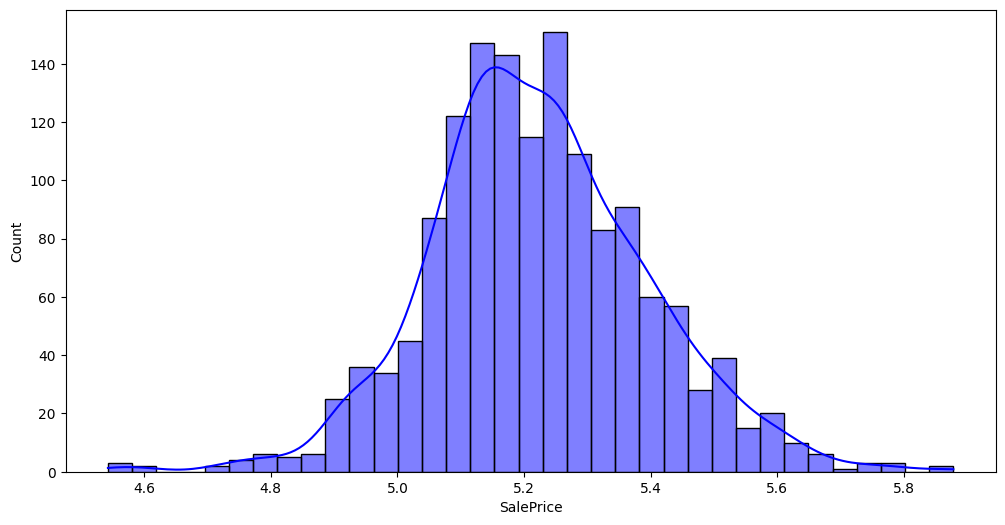

In [52]:
# sns.histplot(df['SalePrice'], kde=True, color="red")
sns.histplot(np.log10(df['SalePrice']), kde=True, color="blue")

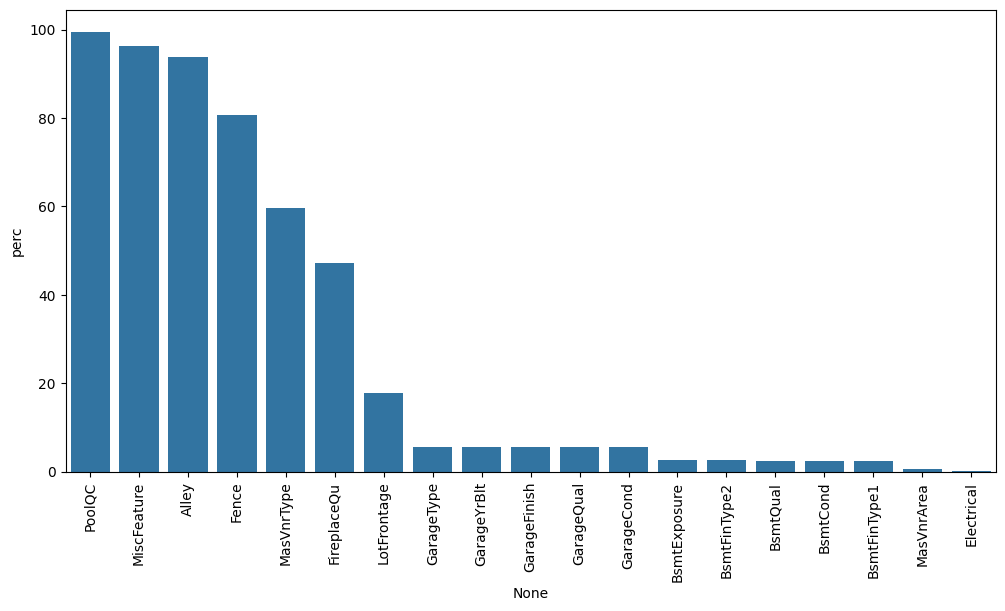

In [53]:
def clac_missing(df: pd.DataFrame):
    total = df.isnull().sum()
    perc = total / len(df) * 100
    result = pd.DataFrame({"missing":total, "perc": perc})
    result = result[result['missing']>0].sort_values("perc", ascending=False)
    return result

missing = clac_missing(df)
sns.barplot(x=missing.index, y=missing['perc']);
plt.xticks(rotation=90);

In [54]:
df.duplicated().sum()

np.int64(0)

### preprocessing

In [55]:
target = df['SalePrice'].copy()
data = df.drop(['SalePrice', 'Id'], axis=1).copy()

In [56]:
data.shape, target.shape

((1460, 79), (1460,))

#### handle missing values

In [57]:
high_missing = list(missing[missing['perc'] > 15].index)
data.drop(high_missing, axis=1, inplace=True)
missing = clac_missing(data)

In [58]:
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

In [59]:
def fill_na_num(df:pd.DataFrame, col, gap = 40):
    mean = df[col].mean()
    median = df[col].median()
    if np.abs(median - mean) < gap: # if there is not an outlier
        df[col].fillna(df[col].mean(), inplace=True)
    else: # if there is an outlier
        df[col].fillna(df[col].median(), inplace=True)
    
    return df

miss_cols = list(set(num_cols).intersection(set(missing.index)))

for col in  miss_cols:
    data = fill_na_num(data, col)



In [64]:
missing = clac_missing(data)

In [ ]:
data[list(missing.index)].dtypes

In [68]:
for col in list(missing.index):
    data[col].fillna(data[col].mode()[0], inplace=True)

#### outlier